### Geopandas Walkthrough

#### import

In [24]:
# %pip install geodatasets
import geodatasets
import geopandas as gpd

path = geodatasets.get_path("nybb")

#### Reading and Writing Files

In [25]:
df = gpd.read_file(path)
df.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


Each `GeoDataFrame` consists of an index, attribute data columns, and a dedicated geometry column. The geometry defines the spatial shape of the feature, which can range from basic types like Points and Polygons to complex structures like MultiPolygons (collections of multiple distinct or adjacent polygons grouped as a single feature).

In [26]:
df.to_file("new_york_boroughs.geojson", driver="GeoJSON")

#### Using files

In [27]:
df = df.set_index("BoroName")
df["area_calculated"] = df.geometry.area
print(df["area_calculated"])

BoroName
Staten Island    1.623822e+09
Queens           3.045214e+09
Brooklyn         1.937478e+09
Manhattan        6.364712e+08
Bronx            1.186926e+09
Name: area_calculated, dtype: float64


##### Grenze und Zentroid

Returns the boundary and center of each shape.

In [28]:
boundaries = df.boundary
centroids = df.centroid

df["boundaries"] = df.boundary
df["centroids"] = df.centroid

##### Measure distances

Once the centroids of geometries are calculated, the straight-line distance between features can be computed using the `.distance()` method.

To ensure accurate calculations in a standard metric unit (meters), the dataset must first be reprojected from its local projection into a metric Coordinate Reference System (CRS). For this region, UTM Zone 18N (EPSG:32618) is used.

In [29]:
manhattan_centroid = df.loc["Manhattan", "centroids"]

df["distance_to_manhattan_km"] = (
    df["centroids"].distance(manhattan_centroid) / 1000
)

print(df["distance_to_manhattan_km"])

BoroName
Staten Island    88.247743
Queens           48.401272
Brooklyn         48.586299
Manhattan         0.000000
Bronx            39.121024
Name: distance_to_manhattan_km, dtype: float64


Custom-built columns can be aggregated directly using built-in methods to obtain the mean, maximum, or sorted values of the distance attributes.

In [30]:
mean_distance = df["distance_to_manhattan_km"].mean()
max_distance = df["distance_to_manhattan_km"].max()
sorted_distances = df["distance_to_manhattan_km"].sort_values()

print(mean_distance, max_distance, sorted_distances)

44.87126782659276 88.24774278873475 BoroName
Manhattan         0.000000
Bronx            39.121024
Queens           48.401272
Brooklyn         48.586299
Staten Island    88.247743
Name: distance_to_manhattan_km, dtype: float64


##### Data Visualization

To display the spatial geometries of the vector map with an associated color scale, use the `.plot()` method with the legend parameter enabled.

<Axes: >

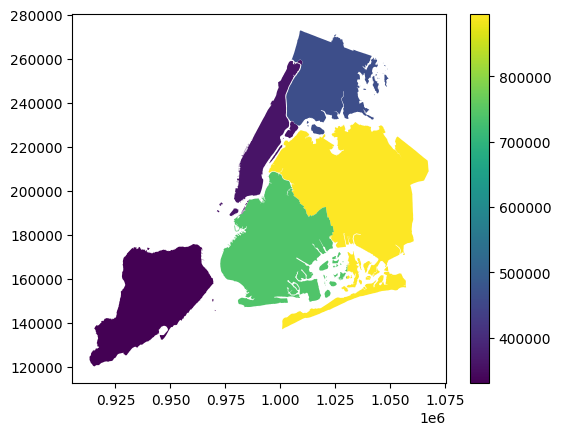

In [31]:
df.plot("Shape_Leng", legend=True)

<Axes: >

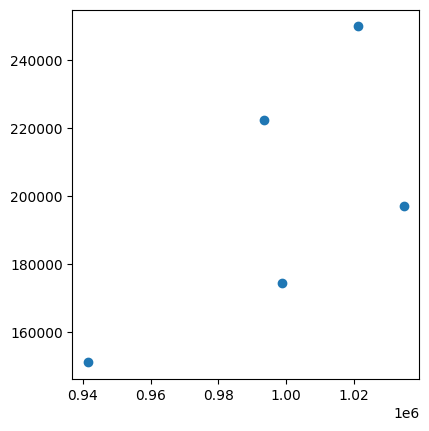

In [32]:
df.set_geometry("centroids").plot()

<Axes: >

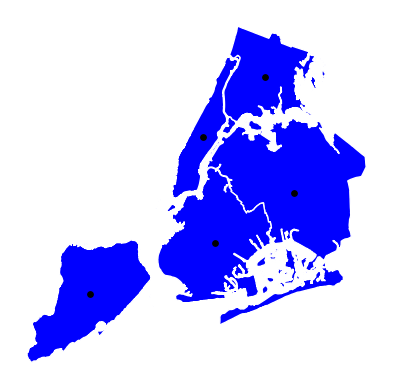

In [33]:
ax = df.plot(color='blue', edgecolor='white')
ax.set_axis_off()
df.set_geometry("centroids").plot(ax=ax, color="black", markersize=15)

##### Buffer

Buffering expands geometries outward by a specified metric distance. This technique is useful for proximity analysis, such as determining structural density, environmental impacts, or spatial intersections within a defined radius around a geographic feature.

Before creating buffers, geometries must be projected into a metric Coordinate Reference System (CRS) to ensure the radius is calculated accurately in meters rather than decimal degrees

In [34]:
df_projected = df.to_crs("EPSG:32618")

df_projected["buffered_geometry"] = df_projected["geometry"].buffer(5000)

df_buffers = df_projected.set_geometry("buffered_geometry")

To visually verify the spatial expansion, the original geometries can be overlaid onto the expanded buffer areas within a single plot.

<Axes: >

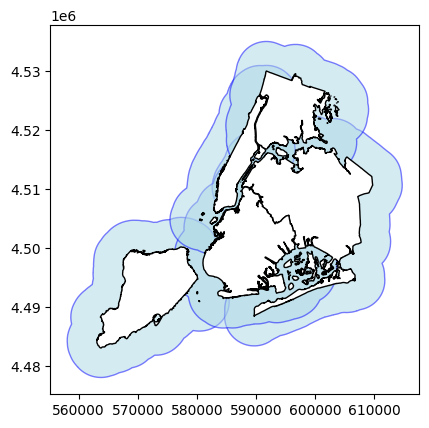

In [35]:
base_axis = df_buffers.plot(color="lightblue", alpha=0.5, edgecolor="blue")
df_projected.plot(ax=base_axis, color="white", edgecolor="black")